# Módulo Visualização de Dados:

Leia o arquivo ecommerce_preparados.csv’ dentro de um dataframe  

Faça uma análise detalhada dos dados, descubra quais dados gostaria de destacar e crie os seguintes gráficos:


*   1 Gráfico de dispersão
*   1 Mapa de calor
*   1 Gráfico de barra
*   1 Gráfico de pizza
*   1 Gráfico de densidade

Adicione títulos nos gráficos e nos eixos para ficar claro os objetivos dos gráficos.

Fiquem a vontade para escolher a biblioteca que quiserem, não esqueçam de comentar os códigos.

Essa atividade é um pouco diferente, vocês terão que construir os códigos nesse arquivo e enviar ou o arquivo ou o link do github com o arquivo publicado para os tutores.

   Unnamed: 0                                                        Título  \
0           0  Pijama Cirurgico  Scrub Roupa Privativa Hospitalar - Unissex   
1           1  Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Masculina Atacado   
2           2         Kit Com 10 Cuecas Boxer Algodão Sem Costura Zorba 781   
3           3   Kit 10 Cuecas Boxer Mash Algodão Cotton Box Original Oferta   
4           4        Kit 3 Short Jeans Feminino Cintura Alta Barato Atacado   

   Nota  N_Avaliações  Desconto                            Marca   Material  \
0   4.0         273.0       NaN  toronto uniformes profissionais  poliéster   
1   4.5        3034.0      18.0                             lupo    algodão   
2   4.7        5682.0      20.0                            zorba    algodão   
3   4.6        1700.0      22.0                             mash    algodão   
4   4.4         507.0       9.0                     menina linda       jean   

       Gênero        Temporada  \
0  Sem gênero   

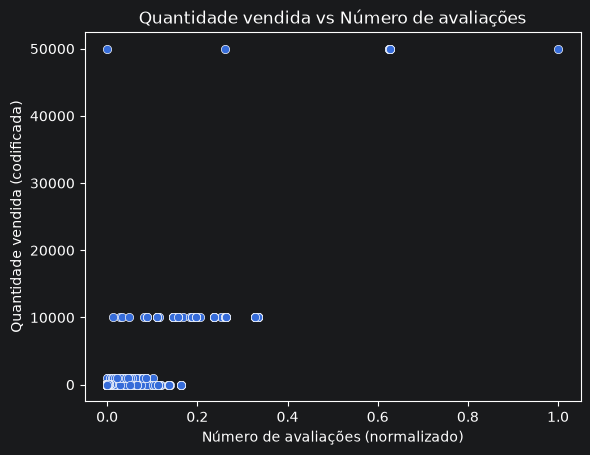

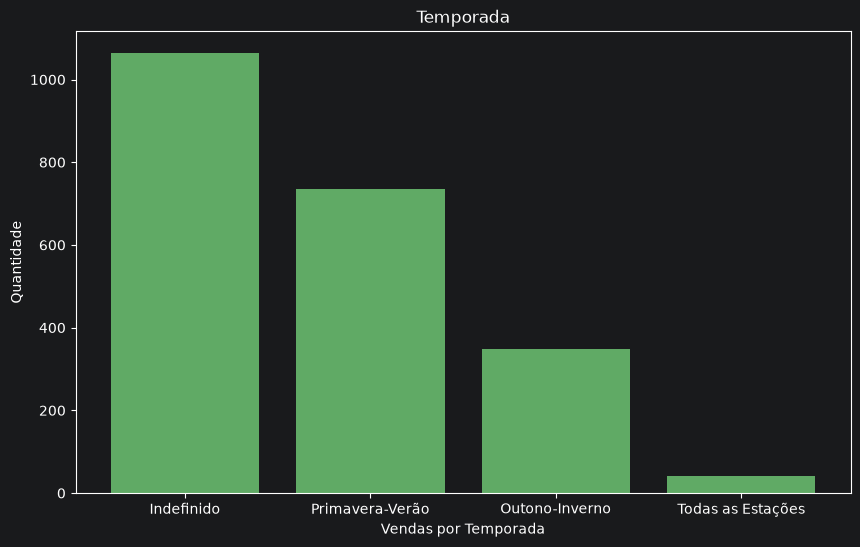

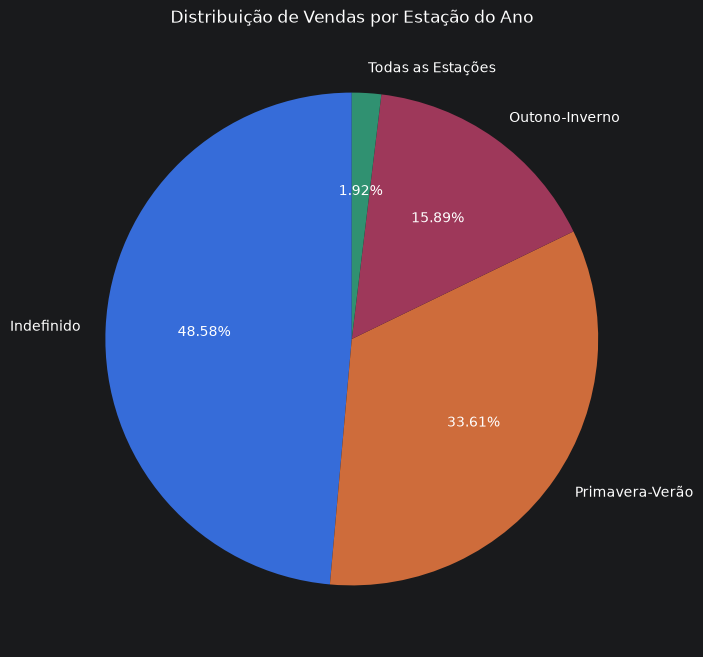

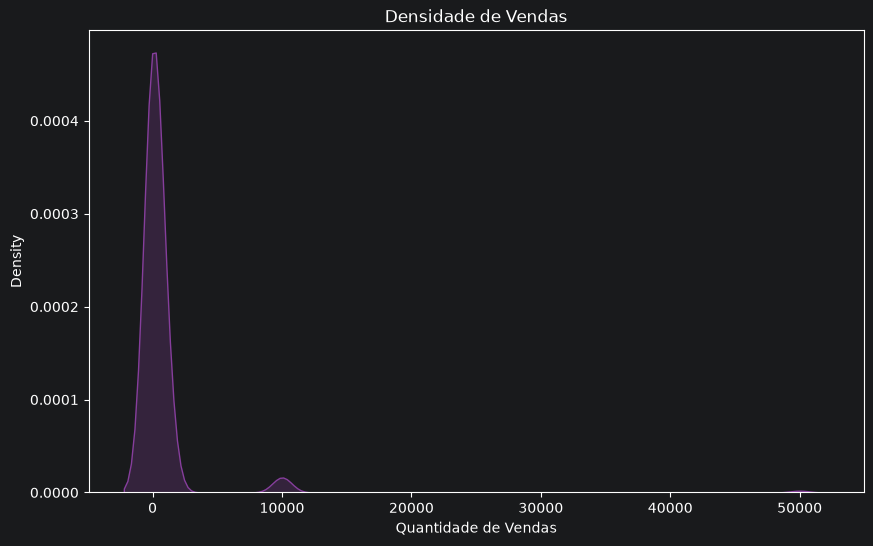

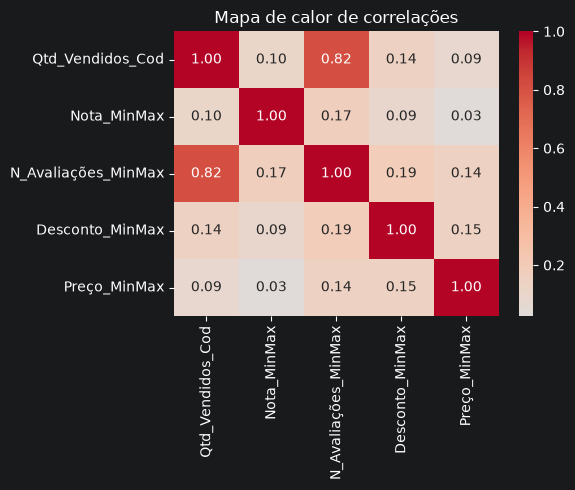

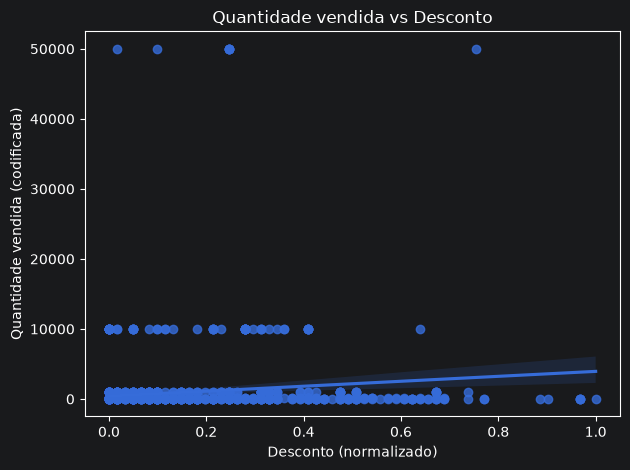

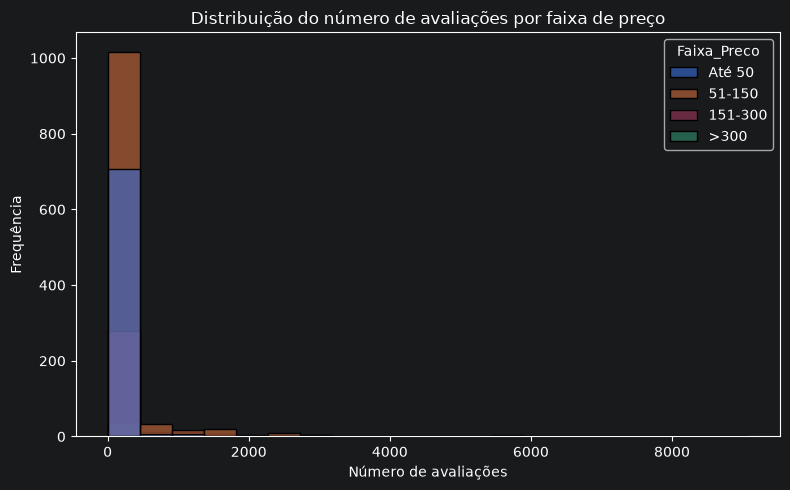

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df = pd.read_csv('ecommerce_preparados.csv')
print(df.head())

#limpeza e tratamento de dados
print('Tipagem dos dados: \n', df.dtypes)
print('Quantidade de valores nulos:', df.isnull().sum())
df['Material'] = df['Material'].fillna('não informado')
df['Gênero'] = df['Gênero'].fillna('não informado')
df = df.fillna(0)
print('Quantidade de valores nulos:', df.isnull().sum())


df = df.drop(columns=['Review3','Review2','Review1'])
print(df.head())

df['Marca'] = df['Marca'].str.title()
df['Material'] = df['Material'].str.title()
df['Temporada'] = df['Temporada'].str.title()
df = df[df['Temporada'] != '2021']

#Criando um dicionário para padronizar os valores
mapeamento_temporadas = {
    'Não Definido': 'Indefinido',
    'Outono/Inverno': 'Outono-Inverno',
    'Outono-Inverno': 'Outono-Inverno',
    'Primavera/Verão': 'Primavera-Verão',
    'Primavera-Verão': 'Primavera-Verão',
    'Primavera/Verão/Outono/Inverno': 'Todas as Estações',
    'Primavera/Verão Outono/Inverno': 'Todas as Estações',
    'Primavera-Verão Outono-Inverno': 'Todas as Estações',
    'Primavera-Verão - Outono-Inverno': 'Todas as Estações'
}

# Aplicando a substituição
df['Temporada'] = df['Temporada'].replace(mapeamento_temporadas)

# Gráfico de dispersâo - Dispersão
sns.scatterplot(data=df, x='N_Avaliações_MinMax', y='Qtd_Vendidos_Cod')
plt.title('Quantidade vendida vs Número de avaliações')
plt.xlabel('Número de avaliações (normalizado)')
plt.ylabel('Quantidade vendida (codificada)')
plt.show()
#Gráfico de barras
x = df['Temporada'].value_counts().index
y = df['Temporada'].value_counts().values

plt.figure(figsize=(10, 6))
plt.bar(x, y, color='#60aa65')
plt.title('Temporada')
plt.xlabel('Vendas por Temporada')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

#Gráfico de Pizza
plt.figure(figsize=(15,8))
plt.pie(y, labels=x, autopct='%.2f%%', startangle=90)
plt.title('Distribuição de Vendas por Estação do Ano')
plt.show()

#Gráfico de Densidade - Quantidade de Vendas
plt.figure(figsize=(10,6))
sns.kdeplot(df['Qtd_Vendidos_Cod'], fill=True, color='#863e9c')
plt.title('Densidade de Vendas')
plt.xlabel('Quantidade de Vendas')
plt.show()

#Gráfico de mapa de calor para analisar a correlação
cols = ['Qtd_Vendidos_Cod', 'Nota_MinMax', 'N_Avaliações_MinMax', 'Desconto_MinMax', 'Preço_MinMax']
corr = df[cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Mapa de calor de correlações')
plt.tight_layout()
plt.show()

#Gráfico de regressão baseado em quanto o desconto influenciou as compras.
sns.regplot(data=df, x='Desconto_MinMax', y='Qtd_Vendidos_Cod')
plt.title('Quantidade vendida vs Desconto')
plt.xlabel('Desconto (normalizado)')
plt.ylabel('Quantidade vendida (codificada)')
plt.tight_layout()
plt.show()

# Criar faixas de preço
df['Faixa_Preco'] = pd.cut(
    df['Preço'],
    bins=[-1, 50, 150, 300, float('inf')],
    labels=['Até 50', '51-150', '151-300', '>300']
)
#Histograma de N_Avaliações, separado por faixas de Preço
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='N_Avaliações',
    hue='Faixa_Preco',
    multiple='layer',
    bins=20,
    alpha=0.6
)
plt.title('Distribuição do número de avaliações por faixa de preço')
plt.xlabel('Número de avaliações')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

